Beijing Air Quality — Análisis Exploratorio de Datos (EDA)
Dataset: UCI PRSA 2013-2017  +  Open-Meteo 2022-2026
Universidad La Salle Arequipa — Ciencia de Datos

CELDA 1 — Montar Google Drive e instalar dependencias  

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


CELDA 2 — Imports y configuración global  

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display, clear_output
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:.2f}".format)

# ── Rutas en Drive ────────────────────────────────────────────────
BASE_HIST = Path("/content/drive/MyDrive/datasets/2013-2017")
BASE_CURR = Path("/content/drive/MyDrive/datasets/2022-2026")

# ── Constantes del dominio ────────────────────────────────────────
STATION_COORDS = {
    "Aotizhongxin":  (39.9821, 116.3937),
    "Changping":     (40.2181, 116.2318),
    "Dingling":      (40.2906, 116.2207),
    "Dongsi":        (39.9292, 116.4177),
    "Guanyuan":      (39.9406, 116.3626),
    "Gucheng":       (39.9147, 116.1861),
    "Huairou":       (40.3241, 116.6374),
    "Nongzhanguan":  (39.9372, 116.4474),
    "Shunyi":        (40.1302, 116.6544),
    "Tiantan":       (39.8822, 116.4117),
    "Wanliu":        (39.9561, 116.2984),
    "Wanshouxigong": (39.8661, 116.3668),
}
ZONA_MAP = {
    "Dingling":"Norte",    "Changping":"Norte",  "Huairou":"Norte",
    "Shunyi":"Norte",      "Aotizhongxin":"Centro","Guanyuan":"Centro",
    "Dongsi":"Centro",     "Nongzhanguan":"Centro","Wanliu":"Centro",
    "Gucheng":"Oeste",     "Tiantan":"Sur",      "Wanshouxigong":"Sur",
}
SEASON_MAP = {12:"Invierno",1:"Invierno",2:"Invierno",
              3:"Primavera",4:"Primavera",5:"Primavera",
              6:"Verano",7:"Verano",8:"Verano",
              9:"Otoño",10:"Otoño",11:"Otoño"}
FEATURES_NUM = ["PM2.5","PM10","SO2","NO2","CO","O3","TEMP","PRES","DEW","WSPM"]
PM25_THRESHOLDS = [
    (0,   35,  "Bueno",                "#2ECC71"),
    (35,  75,  "Moderado",             "#F1C40F"),
    (75,  115, "Insalubre sensibles",  "#E67E22"),
    (115, 150, "Insalubre",            "#E74C3C"),
    (150, 250, "Muy insalubre",        "#8E44AD"),
    (250, 999, "Peligroso",            "#641E16"),
]

# ── Paletas y estilo ──────────────────────────────────────────────
PAL_SEASON  = {"Invierno":"#5B9BD5","Primavera":"#70AD47",
               "Verano":"#FFC000","Otoño":"#ED7D31"}
CRIT_COLOR, MOD_COLOR, OK_COLOR = "#C00000","#FFC000","#70AD47"

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "#F8F9FA",
    "axes.grid": True, "grid.alpha": 0.35,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.family": "sans-serif",
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.labelsize": 11,
})

def pm25_cat(val):
    for lo, hi, cat, _ in PM25_THRESHOLDS:
        if lo <= val < hi:
            return cat
    return "Peligroso"

def pm25_color(val):
    for lo, hi, _, color in PM25_THRESHOLDS:
        if lo <= val < hi:
            return color
    return "#641E16"

print("✓ Librerías y constantes cargadas.")
print(f"  Drive histórico : {BASE_HIST}")
print(f"  Drive actual    : {BASE_CURR}")

✓ Librerías y constantes cargadas.
  Drive histórico : /content/drive/MyDrive/datasets/2013-2017
  Drive actual    : /content/drive/MyDrive/datasets/2022-2026


CELDA 3 — ETL: Carga del dataset histórico 2013-2017   

In [ ]:

def load_historical(base: Path) -> pd.DataFrame:
    csv_files = sorted(base.rglob("*.csv"))
    print(f"  Archivos encontrados en {base}: {len(csv_files)}")
    dfs = []
    for p in csv_files:
        try:
            df = pd.read_csv(p, low_memory=False)

            # Detectar estación por nombre de archivo
            station = next((s for s in STATION_COORDS if s.lower() in p.name.lower()), None)
            if station is None:
                station = df["station"].iloc[0] if "station" in df.columns else p.stem

            # Datetime
            if all(c in df.columns for c in ["year","month","day","hour"]):
                df["datetime"] = pd.to_datetime(df[["year","month","day","hour"]], errors="coerce")
            elif "date" in df.columns:
                df["datetime"] = pd.to_datetime(df["date"], errors="coerce")
            else:
                continue

            df["region"] = station
            lat, lon = STATION_COORDS.get(station, (39.9075, 116.3972))
            df["lat"], df["lon"] = lat, lon
            df["period"] = "2013-2017"

            # Renombrar DEWP → DEW (nombre interno estándar)
            if "DEWP" in df.columns and "DEW" not in df.columns:
                df = df.rename(columns={"DEWP": "DEW"})

            for col in FEATURES_NUM:
                if col in df.columns:
                    df[col] = pd.to_numeric(df[col], errors="coerce")
                    if col in ("PM2.5","PM10","SO2","NO2","CO","O3"):
                        df.loc[df[col] < 0, col] = np.nan
            dfs.append(df)
        except Exception as e:
            print(f"    ⚠ {p.name}: {e}")

    if not dfs:
        raise FileNotFoundError(f"No se encontraron CSVs válidos en {base}")

    out = pd.concat(dfs, ignore_index=True).sort_values("datetime")
    out["month"]  = out["datetime"].dt.month
    out["hour"]   = out["datetime"].dt.hour
    out["year"]   = out["datetime"].dt.year
    out["season"] = out["month"].map(SEASON_MAP)
    out["date"]   = out["datetime"].dt.date
    out["zona"]   = out["region"].map(ZONA_MAP).fillna("Centro")

    # Interpolación lineal PM2.5 por estación
    out = out.sort_values(["region","datetime"])
    out["PM2.5"] = out.groupby("region")["PM2.5"].transform(
        lambda x: x.interpolate("linear").clip(lower=0))

    print(f"  ✓ Registros   : {len(out):,}")
    print(f"  ✓ Estaciones  : {out['region'].nunique()}: {sorted(out['region'].unique())}")
    print(f"  ✓ Rango       : {out['datetime'].min().date()} → {out['datetime'].max().date()}")
    print(f"  ✓ PM2.5 media : {out['PM2.5'].mean():.2f} µg/m³")
    return out

print("Cargando dataset histórico 2013-2017 …")
df_hist = load_historical(BASE_HIST)

Cargando dataset histórico 2013-2017 …
  Archivos encontrados en /content/drive/MyDrive/datasets/2013-2017: 12
  ✓ Registros   : 420,768
  ✓ Estaciones  : 12: ['Aotizhongxin', 'Changping', 'Dingling', 'Dongsi', 'Guanyuan', 'Gucheng', 'Huairou', 'Nongzhanguan', 'Shunyi', 'Tiantan', 'Wanliu', 'Wanshouxigong']
  ✓ Rango       : 2013-03-01 → 2017-02-28
  ✓ PM2.5 media : 79.84 µg/m³


CELDA 4 — ETL: Carga del dataset actual 2022-2026

In [ ]:
def load_current(base: Path) -> pd.DataFrame:
    csv_files = sorted(base.rglob("*.csv"))
    print(f"  Archivos encontrados en {base}: {len(csv_files)}")
    dfs = []
    for p in csv_files:
        try:
            df = pd.read_csv(p, low_memory=False)
            rename = {
                "pm2_5":"PM2.5","pm10":"PM10","so2":"SO2","no2":"NO2",
                "co":"CO","o3":"O3","ozone":"O3",
                "temperature_2m":"TEMP","surface_pressure":"PRES",
                "dewpoint_2m":"DEW","windspeed_10m":"WSPM",
                "precipitation":"RAIN","winddirection_10m":"wd",
            }
            df = df.rename(columns={k:v for k,v in rename.items() if k in df.columns})

            date_col = next((c for c in ["datetime","date","time","timestamp"]
                             if c in df.columns), None)
            if date_col is None: continue
            df["datetime"] = pd.to_datetime(df[date_col], errors="coerce")
            if "region" not in df.columns:
                df["region"] = "Beijing"
            df["lat"] = df.get("lat", 39.9075)
            df["lon"] = df.get("lon", 116.3972)
            df["period"] = "2022-2026"

            if "PM2.5" in df.columns:
                df["PM2.5"] = pd.to_numeric(df["PM2.5"], errors="coerce").clip(lower=0)
            for col in ["PM10","TEMP","PRES","DEW","WSPM","SO2","NO2","CO","O3"]:
                if col in df.columns:
                    df[col] = pd.to_numeric(df[col], errors="coerce")
            dfs.append(df)
        except Exception as e:
            print(f"    ⚠ {p.name}: {e}")

    if not dfs:
        raise FileNotFoundError(f"No se encontraron CSVs válidos en {base}")

    out = pd.concat(dfs, ignore_index=True).dropna(subset=["PM2.5","datetime"])
    out = out.sort_values("datetime").reset_index(drop=True)
    out["month"]  = out["datetime"].dt.month
    out["hour"]   = out["datetime"].dt.hour
    out["year"]   = out["datetime"].dt.year
    out["season"] = out["month"].map(SEASON_MAP)
    out["date"]   = out["datetime"].dt.date

    print(f"  ✓ Registros   : {len(out):,}")
    print(f"  ✓ Zonas       : {sorted(out['region'].unique())}")
    print(f"  ✓ Rango       : {out['datetime'].min().date()} → {out['datetime'].max().date()}")
    print(f"  ✓ PM2.5 media : {out['PM2.5'].mean():.2f} µg/m³")
    return out

print("Cargando dataset actual 2022-2026 …")
df_curr = load_current(BASE_CURR)

Cargando dataset actual 2022-2026 …
  Archivos encontrados en /content/drive/MyDrive/datasets/2022-2026: 3
  ✓ Registros   : 1,294
  ✓ Zonas       : ['Beijing']
  ✓ Rango       : 2022-08-04 → 2026-02-17
  ✓ PM2.5 media : 78.88 µg/m³


CELDA 5 — Estadísticas descriptivas comparadas

In [ ]:
def resumen(df, label):
    pm = df["PM2.5"].dropna()
    return {
        "Período": label,
        "Registros": f"{len(df):,}",
        "PM2.5 media": f"{pm.mean():.2f} µg/m³",
        "PM2.5 std":   f"{pm.std():.2f}",
        "PM2.5 p50":   f"{pm.median():.2f}",
        "PM2.5 p95":   f"{pm.quantile(0.95):.2f}",
        "PM2.5 max":   f"{pm.max():.2f}",
        "% críticos (>150)": f"{(pm>150).mean()*100:.2f}%",
    }

tabla_res = pd.DataFrame([resumen(df_hist,"2013-2017"), resumen(df_curr,"2022-2026")]).set_index("Período")
print("═"*55)
print("  RESUMEN COMPARADO — Ambos períodos")
print("═"*55)
display(tabla_res.T)

mejora_media = (df_hist["PM2.5"].mean() - df_curr["PM2.5"].mean()) / df_hist["PM2.5"].mean() * 100
mejora_crit  = (df_hist["PM2.5"]>150).mean()*100 - (df_curr["PM2.5"]>150).mean()*100
print(f"\n  Mejora media PM2.5  : {'↓' if mejora_media>0 else '↑'}{abs(mejora_media):.1f}%")
print(f"  Mejora días críticos: {'↓' if mejora_crit>0 else '↑'}{abs(mejora_crit):.1f} pp")

═══════════════════════════════════════════════════════
  RESUMEN COMPARADO — Ambos períodos
═══════════════════════════════════════════════════════


Período,2013-2017,2022-2026
Registros,"420,768","1,294"
PM2.5 media,79.84 µg/m³,78.88 µg/m³
PM2.5 std,80.95,47.12
PM2.5 p50,55.00,68.63
PM2.5 p95,242.00,175.94
PM2.5 max,999.00,295.98
% críticos (>150),15.18%,9.12%



  Mejora media PM2.5  : ↓1.2%
  Mejora días críticos: ↓6.1 pp


GRÁFICO 1 — Boxplot PM2.5 por estación + % días críticos

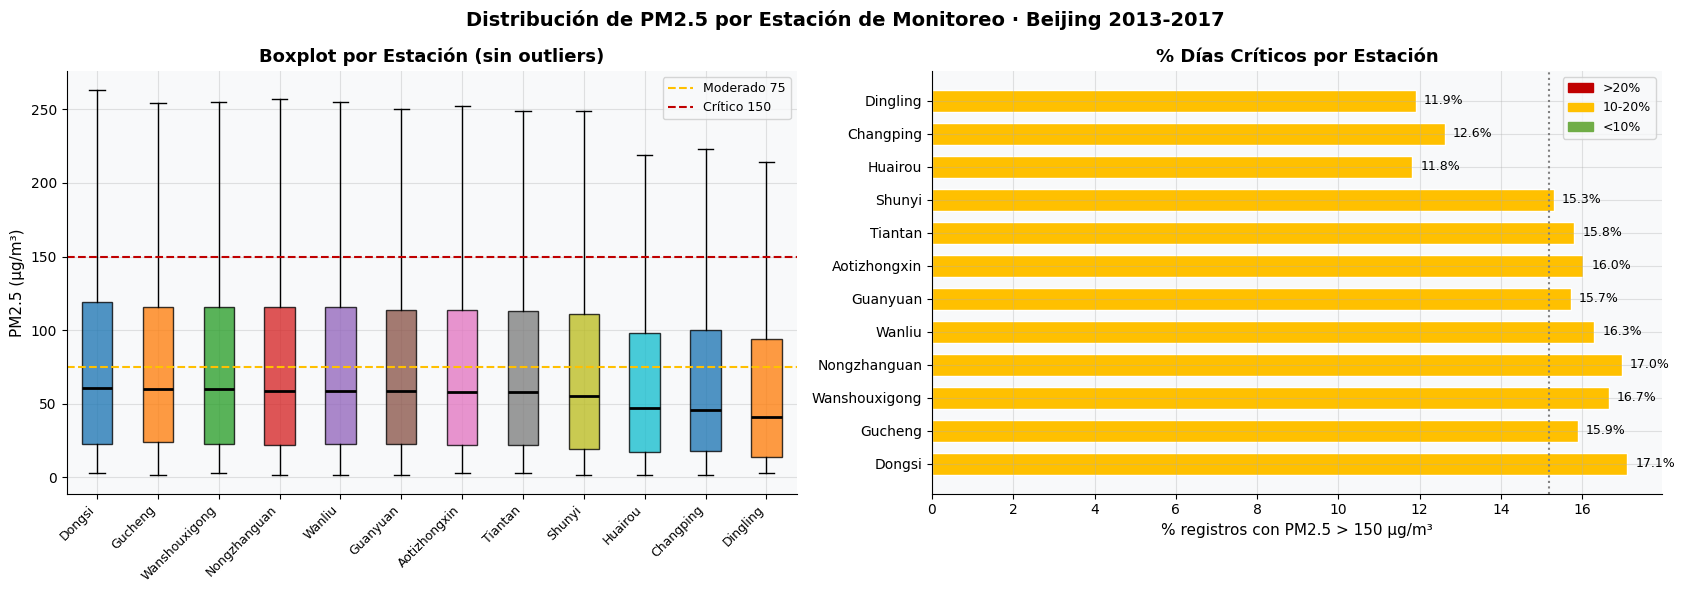

✓ Guardado: grafico1_boxplot_estaciones.png


In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
fig.suptitle("Distribución de PM2.5 por Estación de Monitoreo · Beijing 2013-2017",
             fontsize=14, fontweight="bold")

order = df_hist.groupby("region")["PM2.5"].median().sort_values(ascending=False).index.tolist()
pal   = sns.color_palette("tab10", len(order))

# Panel A: Boxplot
bp_data = [df_hist[df_hist["region"]==s]["PM2.5"].dropna().values for s in order]
bp = axes[0].boxplot(bp_data, patch_artist=True, showfliers=False,
                     medianprops=dict(color="black", lw=2))
for patch, c in zip(bp["boxes"], pal):
    patch.set_facecolor(c); patch.set_alpha(0.78)
axes[0].set_xticklabels(order, rotation=45, ha="right", fontsize=9)
axes[0].set_ylabel("PM2.5 (µg/m³)"); axes[0].set_title("Boxplot por Estación (sin outliers)")
axes[0].axhline(75,  color=MOD_COLOR,  ls="--", lw=1.5, label="Moderado 75")
axes[0].axhline(150, color=CRIT_COLOR, ls="--", lw=1.5, label="Crítico 150")
axes[0].legend(fontsize=9)

# Panel B: % días críticos horizontal
pct = (df_hist.groupby("region")["PM2.5"]
       .apply(lambda x: (x>150).mean()*100)
       .reindex(order))
colors_b = [CRIT_COLOR if v>20 else MOD_COLOR if v>10 else OK_COLOR for v in pct]
bars = axes[1].barh(order, pct.values, color=colors_b, edgecolor="white", height=0.65)
axes[1].axvline(pct.mean(), color="gray", ls=":", lw=1.5, label=f"Media {pct.mean():.1f}%")
for bar, val in zip(bars, pct.values):
    axes[1].text(val+0.2, bar.get_y()+bar.get_height()/2,
                 f"{val:.1f}%", va="center", fontsize=9)
axes[1].set_xlabel("% registros con PM2.5 > 150 µg/m³")
axes[1].set_title("% Días Críticos por Estación")
patches = [mpatches.Patch(color=CRIT_COLOR,label=">20%"),
           mpatches.Patch(color=MOD_COLOR, label="10-20%"),
           mpatches.Patch(color=OK_COLOR,  label="<10%")]
axes[1].legend(handles=patches, fontsize=9)

plt.tight_layout()
plt.savefig("grafico1_boxplot_estaciones.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Guardado: grafico1_boxplot_estaciones.png")

GRÁFICO 2 — Serie temporal mensual: ambos períodos

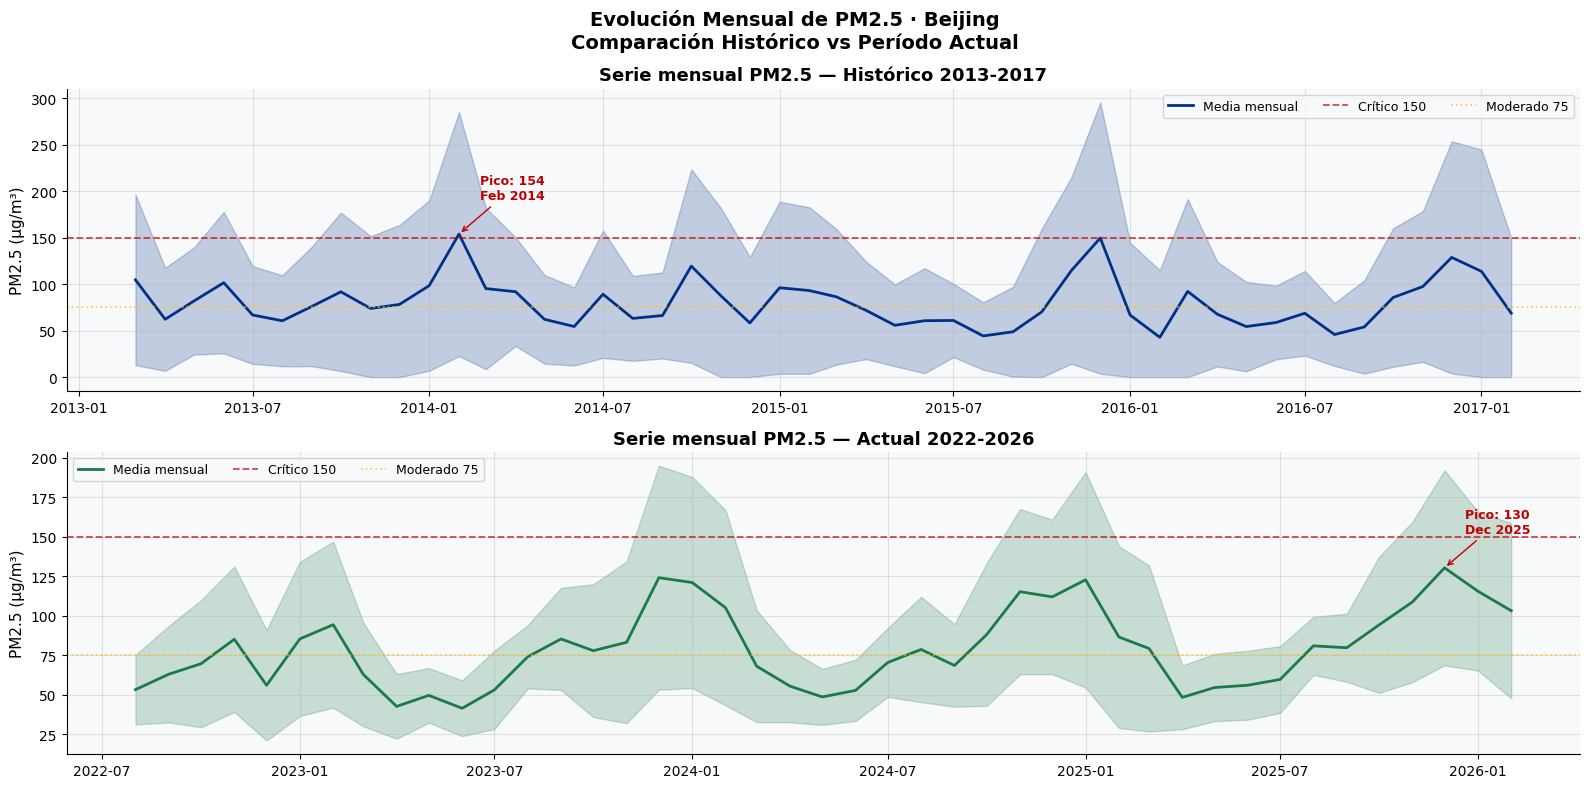

✓ Guardado: grafico2_serie_temporal_ambos.png


In [ ]:

def monthly_agg(df):
    g = df.groupby(df["datetime"].dt.to_period("M"))["PM2.5"].agg(["mean","std"]).reset_index()
    g["datetime"] = g["datetime"].dt.to_timestamp()
    g["lo"] = (g["mean"] - g["std"]).clip(lower=0)
    g["hi"] =  g["mean"] + g["std"]
    return g

mh = monthly_agg(df_hist)
mc = monthly_agg(df_curr)

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=False)

for ax, mg, label, color, period in [
    (axes[0], mh, "Histórico 2013-2017", "#003087", "hist"),
    (axes[1], mc, "Actual 2022-2026",    "#1A7A4A", "curr"),
]:
    ax.fill_between(mg["datetime"], mg["lo"], mg["hi"], alpha=0.22, color=color)
    ax.plot(mg["datetime"], mg["mean"], color=color, lw=2, label="Media mensual")
    ax.axhline(150, color=CRIT_COLOR, ls="--", lw=1.3, alpha=0.7, label="Crítico 150")
    ax.axhline(75,  color=MOD_COLOR,  ls=":",  lw=1.3, alpha=0.7, label="Moderado 75")
    peak = mg.loc[mg["mean"].idxmax()]
    ax.annotate(f"Pico: {peak['mean']:.0f}\n{peak['datetime'].strftime('%b %Y')}",
                xy=(peak["datetime"], peak["mean"]),
                xytext=(15, 25), textcoords="offset points",
                arrowprops=dict(arrowstyle="->", color=CRIT_COLOR),
                color=CRIT_COLOR, fontsize=9, fontweight="bold")
    ax.set_title(f"Serie mensual PM2.5 — {label}", fontweight="bold")
    ax.set_ylabel("PM2.5 (µg/m³)")
    ax.legend(ncol=3, fontsize=9)

fig.suptitle("Evolución Mensual de PM2.5 · Beijing\nComparación Histórico vs Período Actual",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("grafico2_serie_temporal_ambos.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Guardado: grafico2_serie_temporal_ambos.png")

GRÁFICO 3 — Heatmap hora × mes (histórico)

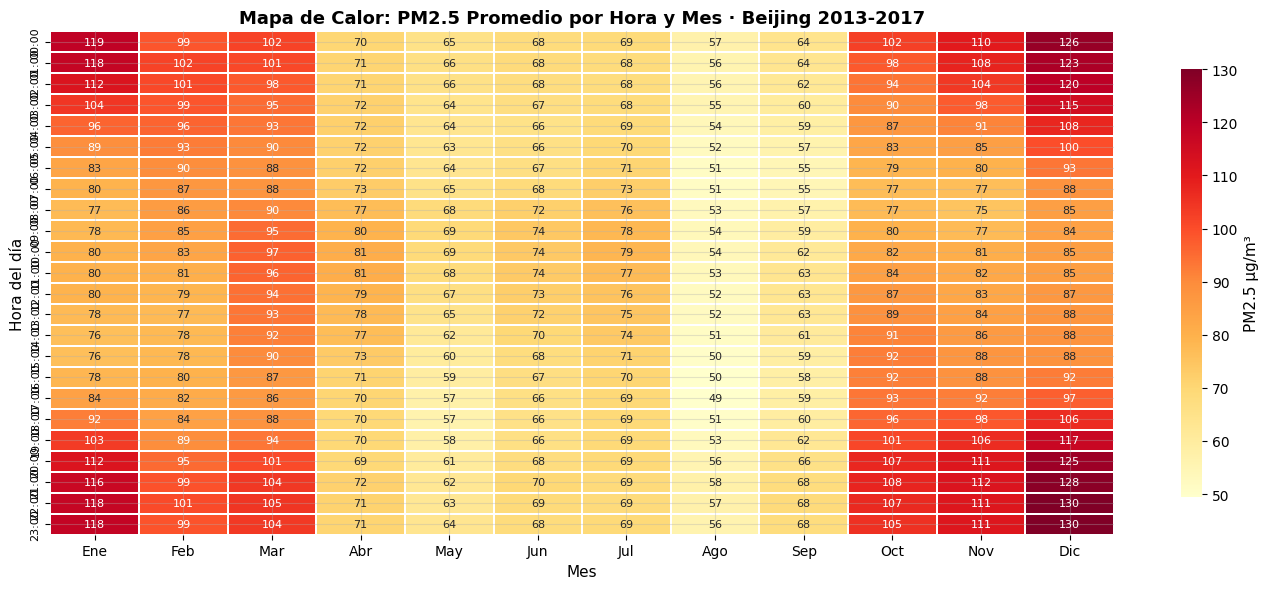

✓ Guardado: grafico3_heatmap_hora_mes.png


In [ ]:

pivot_hm = (df_hist.groupby(["hour","month"])["PM2.5"]
              .mean().unstack("month"))
pivot_hm.columns = ["Ene","Feb","Mar","Abr","May","Jun",
                     "Jul","Ago","Sep","Oct","Nov","Dic"]

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pivot_hm, ax=ax, cmap="YlOrRd", linewidths=0.3, linecolor="white",
            cbar_kws={"label":"PM2.5 µg/m³","shrink":0.85},
            annot=True, fmt=".0f", annot_kws={"size":8})
ax.set_title("Mapa de Calor: PM2.5 Promedio por Hora y Mes · Beijing 2013-2017",
             fontweight="bold")
ax.set_xlabel("Mes"); ax.set_ylabel("Hora del día")
ax.set_yticklabels([f"{h:02d}:00" for h in range(24)], fontsize=8)
plt.tight_layout()
plt.savefig("grafico3_heatmap_hora_mes.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Guardado: grafico3_heatmap_hora_mes.png")


GRÁFICO 4 — Violinplot estacional Norte / Centro / Sur  

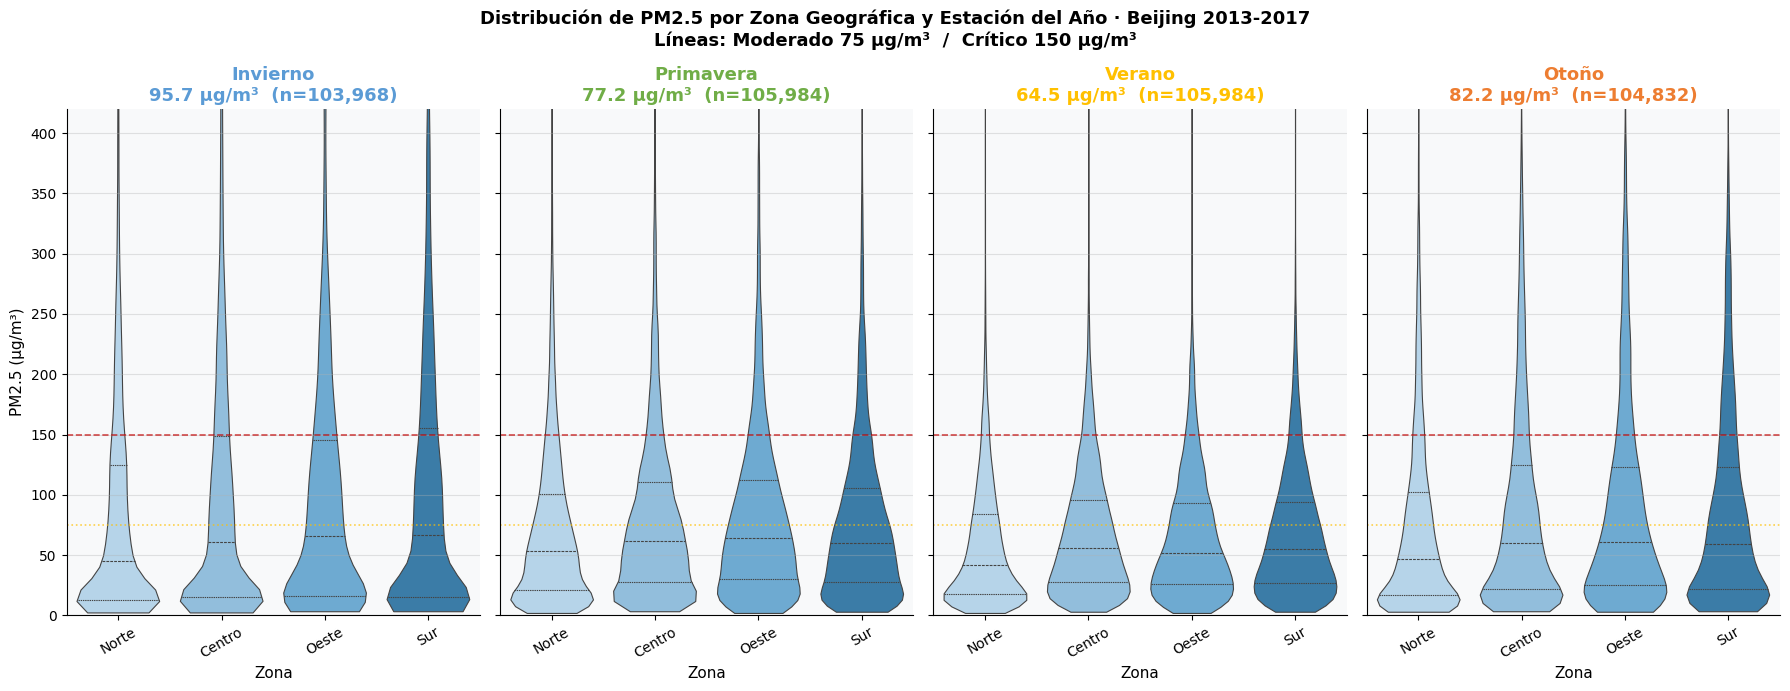

✓ Guardado: grafico4_violinplot_zona_season.png


In [ ]:

seasons_order = ["Invierno","Primavera","Verano","Otoño"]
zonas_order   = ["Norte","Centro","Oeste","Sur"]

fig, axes = plt.subplots(1, 4, figsize=(18, 7), sharey=True)
for ax, season in zip(axes, seasons_order):
    sub = df_hist[df_hist["season"] == season]
    sns.violinplot(data=sub, x="zona", y="PM2.5", order=zonas_order,
                   palette=["#AED6F1","#85C1E9","#5DADE2","#2980B9"],
                   inner="quartile", cut=0, ax=ax, linewidth=0.8)
    n = len(sub)
    mean_s = sub["PM2.5"].mean()
    ax.set_title(f"{season}\n{mean_s:.1f} µg/m³  (n={n:,})",
                 fontweight="bold", color=PAL_SEASON[season])
    ax.set_xlabel("Zona"); ax.set_ylabel("PM2.5 (µg/m³)" if ax == axes[0] else "")
    ax.axhline(150, color=CRIT_COLOR, ls="--", lw=1.2, alpha=0.7)
    ax.axhline(75,  color=MOD_COLOR,  ls=":",  lw=1.2, alpha=0.7)
    ax.tick_params(axis="x", rotation=30); ax.set_ylim(0, 420)

fig.suptitle("Distribución de PM2.5 por Zona Geográfica y Estación del Año · Beijing 2013-2017\n"
             "Líneas: Moderado 75 µg/m³  /  Crítico 150 µg/m³",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("grafico4_violinplot_zona_season.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Guardado: grafico4_violinplot_zona_season.png")

GRÁFICO 5 — Correlación multivariada + scatter viento/PM2.5

In [ ]:
# DIAGNÓSTICO — ejecutar si hay KeyError de columnas
print("Columnas disponibles en df_hist:")
print(sorted(df_hist.columns.tolist()))
print("\nPrimeras filas:")
df_hist.head(2)

Columnas disponibles en df_hist:
['CO', 'DEW', 'NO2', 'No', 'O3', 'PM10', 'PM2.5', 'PRES', 'RAIN', 'SO2', 'TEMP', 'WSPM', 'date', 'datetime', 'day', 'hour', 'lat', 'lon', 'month', 'period', 'region', 'season', 'station', 'wd', 'year', 'zona']

Primeras filas:


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,...,WSPM,station,datetime,region,lat,lon,period,season,date,zona
0,1,2013,3,1,0,4.00,4.00,4.00,7.00,300.00,...,4.40,Aotizhongxin,2013-03-01 00:00:00,Aotizhongxin,39.98,116.39,2013-2017,Primavera,2013-03-01,Centro
1,2,2013,3,1,1,8.00,8.00,4.00,7.00,300.00,...,4.70,Aotizhongxin,2013-03-01 01:00:00,Aotizhongxin,39.98,116.39,2013-2017,Primavera,2013-03-01,Centro


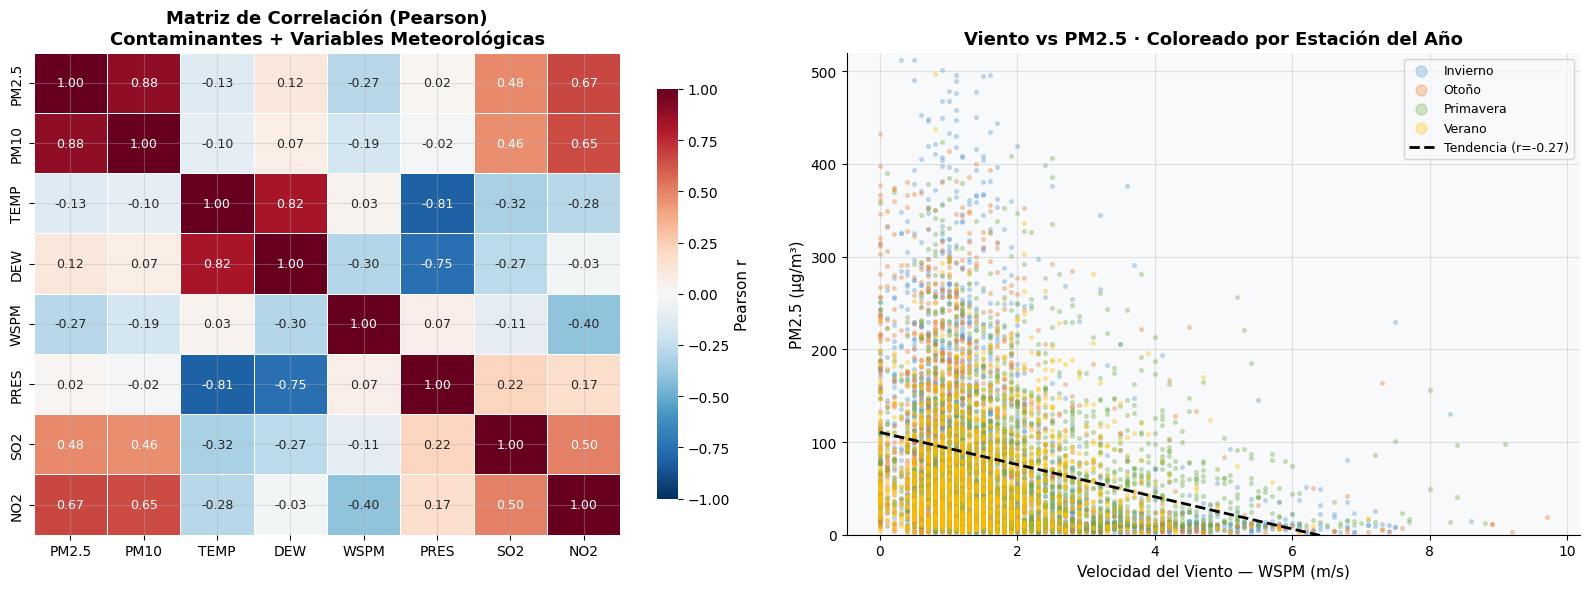

✓ Guardado: grafico5_correlacion_multivariada.png


In [ ]:

FEATS_CORR = ["PM2.5","PM10","TEMP","DEW","WSPM","PRES","SO2","NO2"]
sub_corr = df_hist[FEATS_CORR].dropna()
corr_mat = sub_corr.corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel A: heatmap
sns.heatmap(corr_mat, ax=axes[0], cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", annot_kws={"size":9}, linewidths=0.5,
            cbar_kws={"shrink":0.85,"label":"Pearson r"})
axes[0].set_title("Matriz de Correlación (Pearson)\nContaminantes + Variables Meteorológicas",
                  fontweight="bold")

# Panel B: scatter WSPM vs PM2.5 por estación
sample = df_hist[["WSPM","PM2.5","season"]].dropna().sample(n=min(8000,len(df_hist)), random_state=42)
for season, grp in sample.groupby("season"):
    axes[1].scatter(grp["WSPM"], grp["PM2.5"],
                    c=PAL_SEASON[season], alpha=0.3, s=7, label=season, zorder=2)
ws_v, pm_v = sample["WSPM"].values, sample["PM2.5"].values
coef = np.polyfit(ws_v, pm_v, 1)
x_l  = np.linspace(ws_v.min(), ws_v.max(), 200)
r_wp = corr_mat.loc["WSPM","PM2.5"]
axes[1].plot(x_l, np.polyval(coef, x_l), color="black", lw=2, ls="--",
             label=f"Tendencia (r={r_wp:.2f})")
axes[1].set_xlabel("Velocidad del Viento — WSPM (m/s)")
axes[1].set_ylabel("PM2.5 (µg/m³)")
axes[1].set_title("Viento vs PM2.5 · Coloreado por Estación del Año", fontweight="bold")
axes[1].set_ylim(0, 520); axes[1].legend(fontsize=9, markerscale=3)

plt.tight_layout()
plt.savefig("grafico5_correlacion_multivariada.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Guardado: grafico5_correlacion_multivariada.png")

GRÁFICO 6 — KNN Similitud coseno entre estaciones (heatmap)

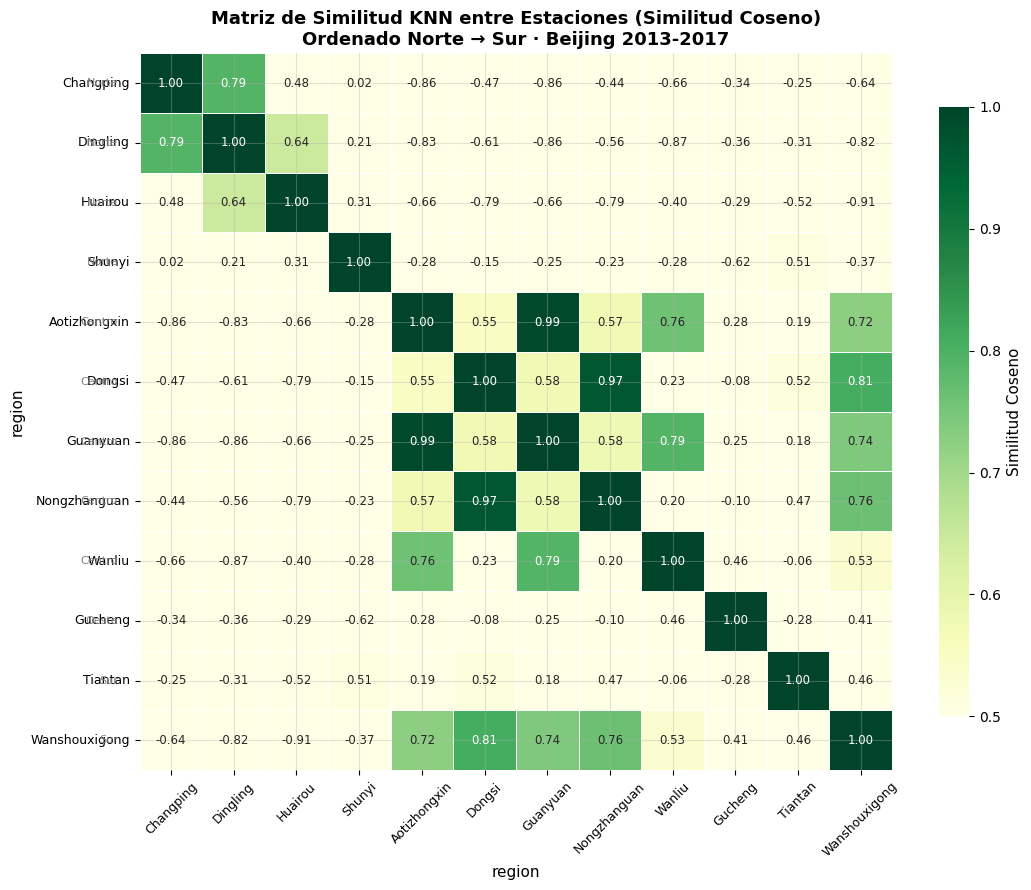

✓ Guardado: grafico6_knn_similitud.png


In [ ]:

feats_knn = [f for f in FEATURES_NUM if f in df_hist.columns]
st_means  = df_hist.groupby("region")[feats_knn].mean().dropna(axis=1, thresh=6).fillna(0)

scaler   = StandardScaler()
X_sc     = scaler.fit_transform(st_means)
sim_mat  = cosine_similarity(X_sc)
sim_df   = pd.DataFrame(sim_mat, index=st_means.index, columns=st_means.index)

# Reordenar por zona geográfica (norte → sur)
zona_order = sorted(st_means.index, key=lambda s: ["Norte","Centro","Oeste","Sur"].index(
    ZONA_MAP.get(s,"Centro")))
sim_df = sim_df.reindex(index=zona_order, columns=zona_order)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(sim_df, ax=ax, cmap="YlGn", vmin=0.5, vmax=1.0,
            annot=True, fmt=".2f", annot_kws={"size":8.5},
            linewidths=0.4, linecolor="white",
            cbar_kws={"label":"Similitud Coseno","shrink":0.85})
ax.set_title("Matriz de Similitud KNN entre Estaciones (Similitud Coseno)\n"
             "Ordenado Norte → Sur · Beijing 2013-2017", fontweight="bold")
ax.tick_params(axis="x", rotation=45, labelsize=9)
ax.tick_params(axis="y", rotation=0,  labelsize=9)

# Etiquetas de zona
for i, st in enumerate(zona_order):
    zona = ZONA_MAP.get(st, "?")
    ax.text(-0.35, i + 0.5, zona, va="center", ha="right",
            fontsize=8, color="gray", transform=ax.transData)

plt.tight_layout()
plt.savefig("grafico6_knn_similitud.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Guardado: grafico6_knn_similitud.png")

GRÁFICO 7 — Comparativa estacional Histórico vs Actual

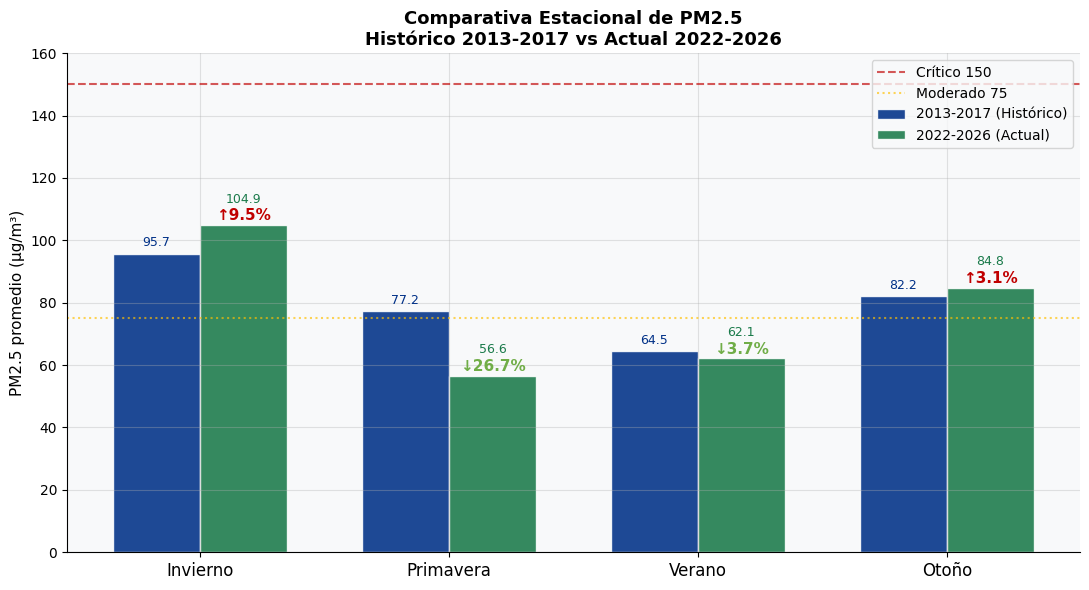

✓ Guardado: grafico7_comparativa_periodos.png


In [ ]:

seasons_order = ["Invierno","Primavera","Verano","Otoño"]
hist_sea = df_hist.groupby("season")["PM2.5"].mean().reindex(seasons_order)
curr_sea = df_curr.groupby("season")["PM2.5"].mean().reindex(seasons_order)

x, w = np.arange(len(seasons_order)), 0.35
fig, ax = plt.subplots(figsize=(11, 6))
b1 = ax.bar(x - w/2, hist_sea.values, w, label="2013-2017 (Histórico)",
            color="#003087", alpha=0.88, edgecolor="white")
b2 = ax.bar(x + w/2, curr_sea.values, w, label="2022-2026 (Actual)",
            color="#1A7A4A", alpha=0.88, edgecolor="white")

for v1, v2, xi in zip(hist_sea.values, curr_sea.values, x):
    if not (np.isnan(v1) or np.isnan(v2)):
        pct  = (v2 - v1) / v1 * 100
        sign = "↑" if pct > 0 else "↓"
        col  = CRIT_COLOR if pct > 0 else OK_COLOR
        ax.text(xi + w/2, v2 + 1.5, f"{sign}{abs(pct):.1f}%",
                ha="center", fontsize=11, color=col, fontweight="bold")

ax.bar_label(b1, fmt="%.1f", padding=3, fontsize=9, color="#003087")
ax.bar_label(b2, fmt="%.1f", padding=14, fontsize=9, color="#1A7A4A")

ax.axhline(150, color=CRIT_COLOR, ls="--", lw=1.5, alpha=0.65, label="Crítico 150")
ax.axhline(75,  color=MOD_COLOR,  ls=":",  lw=1.5, alpha=0.65, label="Moderado 75")
ax.set_xticks(x); ax.set_xticklabels(seasons_order, fontsize=12)
ax.set_ylabel("PM2.5 promedio (µg/m³)"); ax.set_ylim(0, 160)
ax.set_title("Comparativa Estacional de PM2.5\nHistórico 2013-2017 vs Actual 2022-2026",
             fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("grafico7_comparativa_periodos.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Guardado: grafico7_comparativa_periodos.png")

GRÁFICO 8 — INTERACTIVO: Predicción PM2.5 con KNN + ipywidgets

In [ ]:
# ── Pre-computar vectores de estación para el KNN ────────────────
# Ensure 'df_hist' is defined before proceeding. If not, attempt to load it.
if 'df_hist' not in globals():
    print("Warning: df_hist is not defined. Attempting to load historical data.")
    try:
        # Assuming load_historical and BASE_HIST are globally accessible from prior cells.
        df_hist = load_historical(BASE_HIST)
    except NameError:
        print("Error: load_historical or BASE_HIST not found. Please run all preceding setup and data loading cells.")
        raise # Re-raise to indicate a fundamental setup issue
    except Exception as e:
        print(f"Error loading historical data: {e}")
        raise

# Ensure 'DEW' column exists by renaming 'DEWP' if present
if "DEWP" in df_hist.columns and "DEW" not in df_hist.columns:
    df_hist = df_hist.rename(columns={"DEWP": "DEW"})

WEATHER_FEATS = ["TEMP","PRES","DEW","WSPM"]
feats_knn_w   = [f for f in WEATHER_FEATS if f in df_hist.columns]

station_profiles = {}
for st, grp in df_hist.groupby("region"):
    vec = np.array([grp[f].mean() for f in feats_knn_w], dtype=np.float64)
    pm_mean = grp["PM2.5"].mean()
    pm_std  = grp["PM2.5"].std()
    crit_pct = (grp["PM2.5"] > 150).mean() * 100
    station_profiles[st] = {
        "vec": vec, "pm_mean": pm_mean,
        "pm_std": pm_std, "crit_pct": crit_pct,
        "zona": ZONA_MAP.get(st,"?"),
    }

# Matriz normalizada (z-score) para el KNN
names_knn = list(station_profiles.keys())
mat_knn   = np.array([station_profiles[s]["vec"] for s in names_knn], dtype=np.float64)
mu_knn    = mat_knn.mean(axis=0); sd_knn = mat_knn.std(axis=0)
sd_knn[sd_knn < 1e-10] = 1.0
mat_norm  = (mat_knn - mu_knn) / sd_knn

def predict_pm25(temp, pres, dew, wspm, k):
    tv = (np.array([temp, pres, dew, wspm]) - mu_knn) / sd_knn
    dists = [float(np.sqrt(np.sum((tv - mat_norm[i])**2))) for i in range(len(names_knn))]
    idx_sorted = np.argsort(dists)[:k]
    sims = [1/(1+dists[i]) for i in idx_sorted]
    pms  = [station_profiles[names_knn[i]]["pm_mean"] for i in idx_sorted]
    pm_pred = sum(s*p for s,p in zip(sims,pms)) / sum(sims)
    neighbors = [{
        "station": names_knn[i],
        "dist": round(dists[i], 4),
        "sim": round(1/(1+dists[i])*100, 1),
        "pm_mean": round(station_profiles[names_knn[i]]["pm_mean"], 1),
        "crit_pct": round(station_profiles[names_knn[i]]["crit_pct"], 1),
        "zona": station_profiles[names_knn[i]]["zona"],
    } for i in idx_sorted]
    return round(pm_pred, 1), neighbors

# ── Valores típicos por estación del año para los controles ──────
SEASON_DEFAULTS = {
    "Invierno (Dic-Feb)": dict(temp=-3,  pres=1028, dew=-14, wspm=2.0),
    "Primavera (Mar-May)": dict(temp=15, pres=1010, dew=2,   wspm=3.5),
    "Verano (Jun-Ago)":    dict(temp=28, pres=998,  dew=20,  wspm=2.5),
    "Otoño (Sep-Nov)":     dict(temp=12, pres=1018, dew=3,   wspm=2.8),
}

# ── Widgets ───────────────────────────────────────────────────────
style  = {"description_width": "160px"}
layout = widgets.Layout(width="420px")

w_temp = widgets.FloatSlider(min=-20, max=42,  step=0.5, value=15,
    description="🌡  Temperatura (°C)", style=style, layout=layout,
    continuous_update=False, readout_format=".1f")
w_pres = widgets.FloatSlider(min=982, max=1045, step=0.5, value=1010,
    description="🌬  Presión (hPa)",    style=style, layout=layout,
    continuous_update=False, readout_format=".1f")
w_dew  = widgets.FloatSlider(min=-43, max=30,  step=0.5, value=5,
    description="💧 Punto rocío (°C)", style=style, layout=layout,
    continuous_update=False, readout_format=".1f")
w_wspm = widgets.FloatSlider(min=0,   max=14,  step=0.1, value=2.0,
    description="💨 Viento (m/s)",     style=style, layout=layout,
    continuous_update=False, readout_format=".1f")
w_k    = widgets.IntSlider(min=1, max=12, step=1, value=3,
    description="🔢 K vecinos",        style=style, layout=layout,
    continuous_update=False)
w_season_btn = widgets.ToggleButtons(
    options=list(SEASON_DEFAULTS.keys()),
    description="Presets:", button_style="",
    style={"description_width":"60px","button_width":"160px"},
    layout=widgets.Layout(width="700px"))

out_pred = widgets.Output()

# ── Lógica del widget ─────────────────────────────────────────────
def apply_preset(change):
    d = SEASON_DEFAULTS[change["new"]]
    w_temp.value = d["temp"]
    w_pres.value = d["pres"]
    w_dew.value  = d["dew"]
    w_wspm.value = d["wspm"]

def update_plot(*args):
    pm_pred, neighbors = predict_pm25(
        w_temp.value, w_pres.value, w_dew.value, w_wspm.value, w_k.value)

    cat   = pm25_cat(pm_pred)
    color = pm25_color(pm_pred)

    with out_pred:
        clear_output(wait=True)
        fig, axes = plt.subplots(1, 3, figsize=(17, 5))
        fig.patch.set_facecolor("white")
        fig.suptitle(
            f"Predicción KNN de PM2.5  ·  K={w_k.value}  ·  "
            f"TEMP={w_temp.value}°C  PRES={w_pres.value} hPa  "
            f"DEW={w_dew.value}°C  WSPM={w_wspm.value} m/s",
            fontsize=12, fontweight="bold")

        # ── Panel A: Gauge de resultado ───────────────────────────
        ax0 = axes[0]
        ax0.set_facecolor("white"); ax0.set_aspect("equal")
        ax0.set_xlim(-1.4, 1.4); ax0.set_ylim(-0.2, 1.4)
        ax0.axis("off")

        # Arco de colores del gauge
        import matplotlib.patches as mpa
        gauge_colors = [("#2ECC71",0,35),("#F1C40F",35,75),("#E67E22",75,115),
                        ("#E74C3C",115,150),("#8E44AD",150,250),("#641E16",250,999)]
        for gc, lo, hi in gauge_colors:
            span = min(hi, 300) - lo
            frac = span / 300
            start_angle = 180 - (lo/300*180)
            wedge = mpa.Wedge((0,0), 1.1, start_angle - frac*180, start_angle,
                              width=0.28, facecolor=gc, alpha=0.85)
            ax0.add_patch(wedge)

        # Aguja
        needle_angle = np.radians(180 - min(pm_pred,300)/300*180)
        ax0.plot([0, 0.82*np.cos(needle_angle)],
                 [0, 0.82*np.sin(needle_angle)],
                 color="black", lw=3, solid_capstyle="round", zorder=5)
        ax0.add_patch(plt.Circle((0,0), 0.06, color="black", zorder=6))

        ax0.text(0, -0.12, f"{pm_pred} µg/m³", ha="center", va="center",
                 fontsize=22, fontweight="bold", color=color)
        ax0.text(0, -0.30, cat, ha="center", va="center",
                 fontsize=13, color=color, fontweight="bold")
        ax0.set_title("PM2.5 Predicho", fontweight="bold", pad=8)

        # Leyenda del gauge
        for gc, lo, hi in gauge_colors:
            label_text = f"{lo}-{min(hi,999)}: {pm25_cat((lo+min(hi,300))/2)}"
            ax0.plot([], [], color=gc, lw=6, label=label_text)
        ax0.legend(loc="lower center", bbox_to_anchor=(0.5,-0.02),
                   fontsize=7.5, ncol=2, frameon=False)

        # ── Panel B: Barras de vecinos más similares ──────────────
        ax1 = axes[1]
        n_labs = [f"{nb['station']}\n({nb['zona']})" for nb in neighbors]
        n_pms  = [nb["pm_mean"] for nb in neighbors]
        n_sims = [nb["sim"] for nb in neighbors]
        n_cols = [pm25_color(p) for p in n_pms]

        bars = ax1.barh(n_labs, n_pms, color=n_cols, alpha=0.82, edgecolor="white", height=0.55)
        ax1.axvline(pm_pred, color="black", ls="--", lw=2, label=f"Predicción: {pm_pred}")
        for bar, sim, pm in zip(bars, n_sims, n_pms):
            ax1.text(pm + 1, bar.get_y() + bar.get_height()/2,
                     f"{sim:.1f}% sim.", va="center", fontsize=9)
        ax1.set_xlabel("PM2.5 histórico promedio (µg/m³)")
        ax1.set_title(f"Top-{w_k.value} Estaciones Análogas (KNN)", fontweight="bold")
        ax1.axvline(150, color=CRIT_COLOR, ls=":", lw=1.3, alpha=0.6)
        ax1.axvline(75,  color=MOD_COLOR,  ls=":", lw=1.3, alpha=0.6)
        ax1.legend(fontsize=9); ax1.invert_yaxis()

        # ── Panel C: Impacto de cada variable (diferencia vs media) ─
        ax2 = axes[2]
        ref = {"TEMP": df_hist["TEMP"].mean(), "PRES": df_hist["PRES"].mean(),
               "DEW":  df_hist["DEW"].mean(),  "WSPM": df_hist["WSPM"].mean()}
        vals_in  = [w_temp.value, w_pres.value, w_dew.value, w_wspm.value]
        delta_z  = [(v - mu_knn[i]) / sd_knn[i] for i, v in enumerate(vals_in)]
        feat_labs = ["Temperatura\n(TEMP)","Presión\n(PRES)",
                     "Punto de\nRocío (DEW)","Viento\n(WSPM)"]
        delta_cols = [CRIT_COLOR if d > 0 else OK_COLOR for d in delta_z]
        ax2.barh(feat_labs, delta_z, color=delta_cols, alpha=0.82,
                 edgecolor="white", height=0.5)
        ax2.axvline(0, color="black", lw=1.2)
        for i, (d, v) in enumerate(zip(delta_z, vals_in)):
            ax2.text(d + (0.04 if d >= 0 else -0.04), i,
                     f"{v:.1f}", va="center",
                     ha="left" if d >= 0 else "right", fontsize=10, fontweight="bold")
        ax2.set_xlabel("Desviaciones estándar vs. media histórica")
        ax2.set_title("Alejamiento de la condición media\n(Z-score de cada variable)", fontweight="bold")
        crit_p = mpatches.Patch(color=CRIT_COLOR, label="Por encima de la media")
        ok_p   = mpatches.Patch(color=OK_COLOR,   label="Por debajo de la media")
        ax2.legend(handles=[crit_p, ok_p], fontsize=9, loc="lower right")

        plt.tight_layout()
        plt.show()

        # Tabla de vecinos
        print(f"\n{'─'*72}")
        print(f"  {'Estación':<20} {'Zona':<8} {'Similitud':>10} "
              f"{'PM2.5 hist':>12} {'% Críticos':>12}")
        print(f"{'─'*72}")
        for nb in neighbors:
            print(f"  {nb['station']:<20} {nb['zona']:<8} {nb['sim']:>9.1f}% "
                  f"{nb['pm_mean']:>10.1f} µg/m³  {nb['crit_pct']:>8.1f}%")
        print(f"{'─'*72}")
        print(f"  → PM2.5 predicho: {pm_pred} µg/m³  |  Categoría: {cat}")

w_season_btn.observe(apply_preset, names="value")
for w in [w_temp, w_pres, w_dew, w_wspm, w_k]:
    w.observe(update_plot, names="value")

# ── Render inicial ────────────────────────────────────────────────
header = widgets.HTML(
    "<h3 style='margin:8px 0; color:#003087'>🔮 Predicción Interactiva de PM2.5 con KNN</h3>"
    "<p style='color:gray;font-size:12px'>Ajusta las condiciones meteorológicas y observa"
    " cómo cambia la predicción en tiempo real.</p>")

controls = widgets.VBox([
    header,
    widgets.HTML("<b>Preset por Estación del Año:</b>"),
    w_season_btn,
    widgets.HTML("<hr><b>Condiciones Meteorológicas:</b>"),
    widgets.HBox([widgets.VBox([w_temp, w_pres]), widgets.VBox([w_dew, w_wspm, w_k])]),
])

display(controls, out_pred)
update_plot()

Output()

CELDA FINAL — Resumen de archivos generados

In [ ]:

import glob
from google.colab import files

graficos = sorted(glob.glob("grafico*.png"))
print("╔══════════════════════════════════════════════════════╗")
print("║           GRÁFICOS GENERADOS Y GUARDADOS            ║")
print("╠══════════════════════════════════════════════════════╣")
desc = {
    "grafico1_boxplot_estaciones.png":    "Boxplot PM2.5 + % días críticos por estación",
    "grafico2_serie_temporal_ambos.png":  "Serie mensual PM2.5 — ambos períodos",
    "grafico3_heatmap_hora_mes.png":      "Heatmap hora × mes (histórico)",
    "grafico4_violinplot_zona_season.png":"Violinplot zona geográfica × estación del año",
    "grafico5_correlacion_multivariada.png":"Correlación Pearson + scatter viento/PM2.5",
    "grafico6_knn_similitud.png":         "Similitud KNN coseno entre estaciones",
    "grafico7_comparativa_periodos.png":  "Comparativa estacional 2013-17 vs 2022-26",
}
for g in graficos:
    kb = Path(g).stat().st_size / 1024
    print(f"║  ✓ {g:<42} {kb:5.0f} KB ║")
    print(f"║    {desc.get(g,''):<50} ║")
print("╚══════════════════════════════════════════════════════╝")

# Descomentar para descargar todos:
for g in graficos:
    files.download(g)

╔══════════════════════════════════════════════════════╗
║           GRÁFICOS GENERADOS Y GUARDADOS            ║
╠══════════════════════════════════════════════════════╣
║  ✓ grafico1_boxplot_estaciones.png              172 KB ║
║    Boxplot PM2.5 + % días críticos por estación       ║
║  ✓ grafico2_serie_temporal_ambos.png            335 KB ║
║    Serie mensual PM2.5 — ambos períodos               ║
║  ✓ grafico3_heatmap_hora_mes.png                256 KB ║
║    Heatmap hora × mes (histórico)                     ║
║  ✓ grafico4_violinplot_zona_season.png          278 KB ║
║    Violinplot zona geográfica × estación del año      ║
║  ✓ grafico5_correlacion_multivariada.png        466 KB ║
║    Correlación Pearson + scatter viento/PM2.5         ║
║  ✓ grafico6_knn_similitud.png                   220 KB ║
║    Similitud KNN coseno entre estaciones              ║
║  ✓ grafico7_comparativa_periodos.png             88 KB ║
║    Comparativa estacional 2013-17 vs 2022-26          ║
╚══════════

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>